In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision.datasets import CIFAR10


In [2]:
# Dataset & dataloader
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomCrop(32, padding=4),
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])
trainset = CIFAR10(root = "./Data",train = True, download = True,transform = transform)
testset = CIFAR10(root = "./Data",train = False, download = True,transform = transform)


In [3]:
trainset

Dataset CIFAR10
    Number of datapoints: 50000
    Root location: ./Data
    Split: Train
    StandardTransform
Transform: Compose(
               RandomHorizontalFlip(p=0.5)
               RandomCrop(size=(32, 32), padding=4)
               ToTensor()
               Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
           )

In [4]:
train_loader = DataLoader(trainset,batch_size = 64,shuffle = True)
test_loader = DataLoader(testset,batch_size = 64)

BUILD the CNN

In [5]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        self.conv_layers = nn.Sequential(
            
        
            
            nn.Conv2d(3,32,kernel_size=3,padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
        
            nn.Conv2d(32,64,kernel_size=3,padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
        
            nn.Conv2d(64,128,kernel_size=3,padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2,2)
        )

        self.fc_layers = nn.Sequential(
            
            nn.Linear(4*4*128,256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256,10)
        )
            

    def forward(self, x):
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        return x

In [6]:
model = CNN()

In [7]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr = 0.001)


training the CNN

In [8]:
train_losses = []
accuracies = []

epochs = 15

for epoch in range(epochs):
    print(f"epoch {epoch+1} start")
    epoch_training_loss = 0.0

    for images, labels in train_loader:
        
        optimizer.zero_grad()
        output = model(images)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()
        epoch_training_loss += loss.item()

    # Loss store
    avg_loss = epoch_training_loss / len(train_loader)
    train_losses.append(avg_loss)
    
torch.save(model.state_dict(), "model.pth")
   

epoch 1 start
epoch 2 start
epoch 3 start
epoch 4 start
epoch 5 start
epoch 6 start
epoch 7 start
epoch 8 start
epoch 9 start
epoch 10 start
epoch 11 start
epoch 12 start
epoch 13 start
epoch 14 start
epoch 15 start


In [9]:
# evaluate our cnn
correct_labels = 0
total_labels = 0
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
       
        outputs = model(images)
        _, predicted = torch.max(outputs,1)
        correct_labels += (predicted == labels).sum().item()
        total_labels += labels.size(0)

print(f"accuracy = {correct_labels/total_labels * 100}")
        

accuracy = 77.31


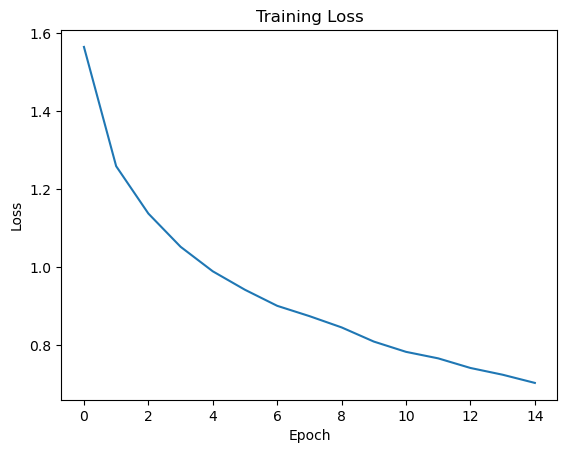

In [10]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_losses)
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()